In [20]:
import numpy as np

# Щоб результат можна було повторити
np.random.seed(42)

# 1. Генеруємо 100 випадкових значень для x1 і x2
x1 = np.random.rand(100)
x2 = np.random.rand(100)

# 2. Функція для обчислення y за поліномом 2-го степеня
def polynomial(x1, x2):
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2

# 3. Обчислюємо цільову змінну y
y = polynomial(x1, x2)

# 4. Формуємо масив ознак X розмірності (100, 2)
X = np.column_stack((x1, x2))

# 5. Перевіряємо результати
print("Форма X:", X.shape)   # (100, 2)
print("Форма y:", y.shape)   # (100,)

print("\nПерші 5 рядків X:")
print(X[:5])

print("\nПерші 5 значень y:")
print(y[:5])

Форма X: (100, 2)
Форма y: (100,)

Перші 5 рядків X:
[[0.37454012 0.03142919]
 [0.95071431 0.63641041]
 [0.73199394 0.31435598]
 [0.59865848 0.50857069]
 [0.15601864 0.90756647]]

Перші 5 значень y:
[ 1.47756243  3.46411331  2.48699153  0.86241965 -1.04478571]


In [21]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# Генеруємо випадкові ознаки
np.random.seed(42)

x1 = np.random.rand(100)
x2 = np.random.rand(100)

# формуємо матрицю ознак
X = np.column_stack((x1, x2))

# створюємо поліноміальні ознаки
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

# перевіряємо результат
print("Original shape:", X.shape)
print("Polynomial shape:", X_poly.shape)

# назви ознак
print("Feature names:")
print(poly.get_feature_names_out())

Original shape: (100, 2)
Polynomial shape: (100, 5)
Feature names:
['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']


In [22]:
import numpy as np


def add_bias(X):
    """
    Додає стовпець одиниць для вільного члена.
    """
    X = np.asarray(X, dtype=float)
    return np.c_[np.ones((X.shape[0], 1)), X]


def mse_loss(X, y, w):
    """
    Середньоквадратична помилка:
    J(w) = (1/n) * sum((Xw - y)^2)
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    preds = X @ w
    return np.mean((preds - y) ** 2)


def compute_gradient(X, y, w):
    """
    Градієнт для MSE:
    grad = (2/n) * X^T (Xw - y)
    """
    n = X.shape[0]
    preds = X @ w
    error = preds - y
    grad = (2.0 / n) * (X.T @ error)
    return grad


def polynomial_regression_gradient_descent(
    X, y, learning_rate=0.01, n_iterations=5000, random_state=42
):
    """
    Batch Gradient Descent для поліноміальної регресії.

    Параметри:
        X : матриця ознак (без bias)
        y : цільовий вектор
        learning_rate : крок навчання
        n_iterations : кількість ітерацій
        random_state : для відтворюваності

    Повертає:
        w : вектор ваг
        loss_history : список значень MSE
    """
    X = add_bias(X)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    w = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])

    loss_history = []

    for _ in range(n_iterations):
        grad = compute_gradient(X, y, w)
        w -= learning_rate * grad
        loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_SGD(
    X,
    y,
    learning_rate=0.01,
    n_epochs=200,
    random_state=42,
    shuffle=True
):
    """
    Stochastic Gradient Descent.
    На кожному кроці оновлюємо ваги по одному об'єкту.
    """
    X = add_bias(X)
    y = np.asarray(y, dtype=float).reshape(-1)

    n_samples, n_features = X.shape
    rng = np.random.default_rng(random_state)
    w = rng.normal(loc=0.0, scale=0.01, size=n_features)

    loss_history = []

    for _ in range(n_epochs):
        indices = np.arange(n_samples)

        if shuffle:
            rng.shuffle(indices)

        for i in indices:
            xi = X[i:i+1]         # shape (1, n_features)
            yi = y[i:i+1]         # shape (1,)

            # Градієнт для одного спостереження
            error = xi @ w - yi   # shape (1,)
            grad = 2.0 * xi.T @ error
            grad = grad.reshape(-1)

            w -= learning_rate * grad

        loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_rmsprop(
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000,
    beta=0.9,
    epsilon=1e-8,
    random_state=42
):
    """
    RMSProp:
    s_t = beta * s_{t-1} + (1 - beta) * grad^2
    w   = w - lr * grad / (sqrt(s_t) + eps)
    """
    X = add_bias(X)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    w = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])

    s = np.zeros_like(w)
    loss_history = []

    for _ in range(n_iterations):
        grad = compute_gradient(X, y, w)

        s = beta * s + (1.0 - beta) * (grad ** 2)
        w -= learning_rate * grad / (np.sqrt(s) + epsilon)

        loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_adam(
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    random_state=42
):
    """
    Adam:
    m_t = beta1 * m_{t-1} + (1-beta1) * grad
    v_t = beta2 * v_{t-1} + (1-beta2) * grad^2

    bias correction:
    m_hat = m_t / (1 - beta1^t)
    v_hat = v_t / (1 - beta2^t)
    """
    X = add_bias(X)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    w = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])

    m = np.zeros_like(w)
    v = np.zeros_like(w)
    loss_history = []

    for t in range(1, n_iterations + 1):
        grad = compute_gradient(X, y, w)

        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)

        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)

        w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_nadam( # +
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    random_state=42
):
    """
    Nadam = Adam + Nesterov momentum.

    Спрощена формула:
    m_t = beta1 * m_{t-1} + (1-beta1) * grad
    v_t = beta2 * v_{t-1} + (1-beta2) * grad^2

    m_hat = m_t / (1 - beta1^t)
    v_hat = v_t / (1 - beta2^t)

    nesterov_m = beta1 * m_hat + ((1-beta1) * grad) / (1 - beta1^t)
    """
    X = add_bias(X)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    w = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])

    m = np.zeros_like(w)
    v = np.zeros_like(w)
    loss_history = []

    for t in range(1, n_iterations + 1):
        grad = compute_gradient(X, y, w)

        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)

        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)

        nesterov_m = beta1 * m_hat + ((1.0 - beta1) * grad) / (1.0 - beta1 ** t)

        w -= learning_rate * nesterov_m / (np.sqrt(v_hat) + epsilon)

        loss_history.append(mse_loss(X, y, w))

    return w, loss_history

In [186]:
# =========================
# 1. Єдина конфігурація методів
# =========================
method_configs = {
    "GD": {
        "func": polynomial_regression_gradient_descent,
        "params": {"learning_rate": 0.3, "n_iterations": 5000}
    },
    "SGD": {
        "func": polynomial_regression_SGD,
        "params": {"learning_rate": 0.015, "n_epochs": 1000}
    },
    "RMSProp": {
        "func": polynomial_regression_rmsprop,
        "params": {"learning_rate": 0.002, "n_iterations": 5000}
    },
    "Adam": {
        "func": polynomial_regression_adam,
        "params": {"learning_rate": 0.05, "n_iterations": 3000}
    },
    "Nadam": {
        "func": polynomial_regression_nadam,
        "params": {"learning_rate": 0.05, "n_iterations": 3000}
    }
}

In [187]:
timings = {}
methods = {}

for method_name, config in method_configs.items():

    func = config["func"]
    params = config["params"]

    methods[method_name] = func(X_poly, y, **params)
    timings[method_name] = %timeit -o func(X_poly, y, **params)

86 ms ± 19.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
674 ms ± 9.88 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
115 ms ± 17.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
75.2 ms ± 2.66 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
85 ms ± 1.52 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [190]:
# =========================
# 4. Таблиця коефіцієнтів
# =========================
coef_names = ["bias"] + list(poly.get_feature_names_out())

rows = []

for method_name, (weights, losses) in methods.items():
    row = {"method": method_name}

    for name, coef in zip(coef_names, weights):
        row[name] = coef

    row["Final MSE"] = losses[-1]
    row["Time (ms)"] = timings[method_name].average * 1000
    #row["Std (ms)"] = timings[method_name].stdev * 1000
    #row["Кількість запусків"] = timings[method_name].loops

    rows.append(row)


import pandas as pd


results_df = pd.DataFrame(rows)#.set_index("method")
results_df = results_df.sort_values(by="Final MSE").reset_index(drop=True)
display(results_df.round(6))



,method,bias,x0,x1,x0^2,x0 x1,x1^2,Final MSE,Time (ms)
0,Nadam,-0.000003,3.000014,-5.999996,3.999987,-2.000003,4.999997,0.00000,85.031046
1,Adam,-0.000008,3.000036,-5.999989,3.999968,-2.000007,4.999993,0.00000,75.196891
2,SGD,-0.001968,3.004170,-5.993277,3.996697,-2.001797,4.994393,0.00000,674.434184
3,GD,-0.002161,3.004511,-5.992738,3.996420,-2.001955,4.993922,0.00000,85.983719
4,RMSProp,-0.003855,3.010280,-5.982326,3.993936,-2.003506,4.987161,0.00001,115.057518


Adam та Nadam показали найкращу обчислювальну ефективність, оскільки вони поєднують високу точність та невеликий час виконання.

Класичний Gradient Descent також забезпечує хорошу точність, але потребує більшої кількості ітерацій для досягнення збіжності.

Метод RMSProp демонструє стабільну роботу, однак через додаткові обчислення адаптивного кроку його час виконання дещо більший.

Метод SGD виявився найповільнішим у цьому експерименті, оскільки оновлення параметрів виконується після кожного спостереження, що значно збільшує кількість обчислень. Крім того, SGD має більш шумну збіжність.

Найбільш ефективними алгоритмами оптимізації в цьому експерименті є Adam та Nadam, оскільки вони забезпечують швидку збіжність, високу точність та невеликий час виконання.

Adam показав найкраще співвідношення між точністю та швидкістю роботи, тому його можна вважати найбільш обчислювально ефективним методом для даної задачі.

SGD виявився найменш ефективним через велику кількість оновлень параметрів.

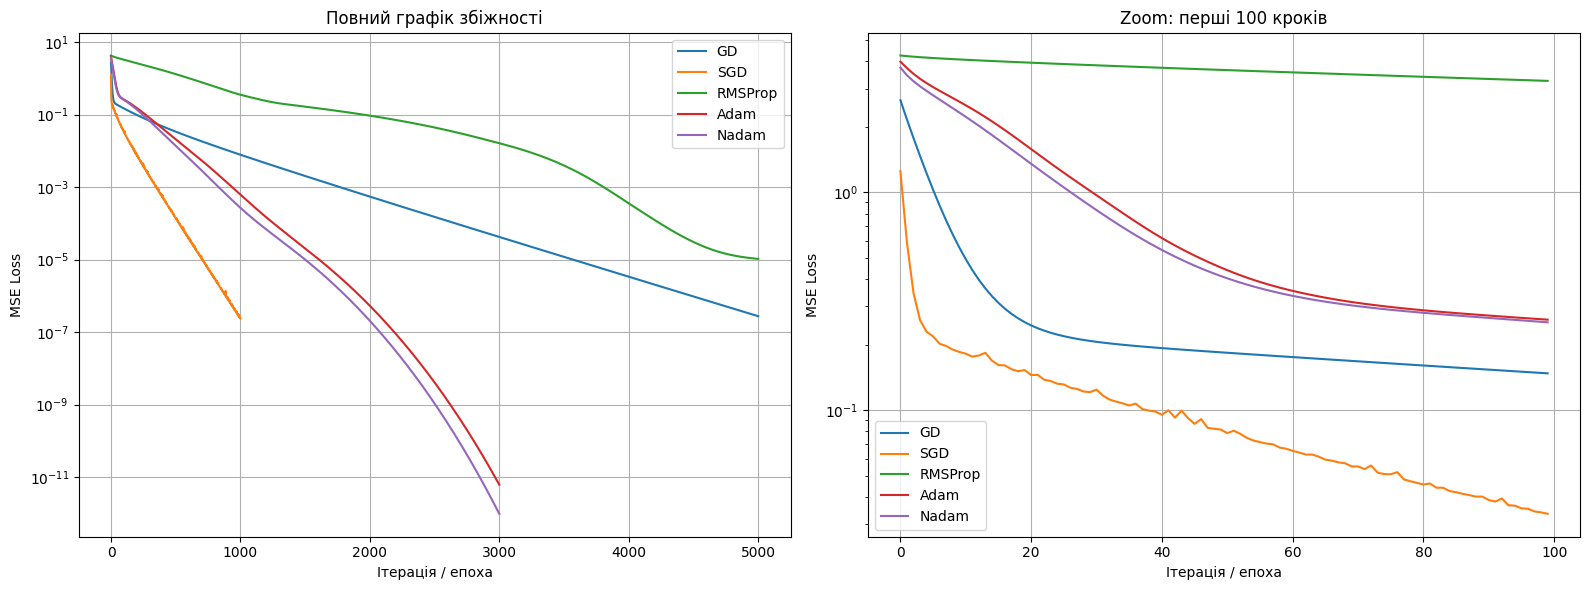

In [193]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Лівий графік: весь хід навчання
for method_name, (weights, losses) in methods.items():
    axes[0].plot(losses, label=method_name)

axes[0].set_xlabel("Ітерація / епоха")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Повний графік збіжності")
axes[0].set_yscale("log")
axes[0].grid(True)
axes[0].legend()

# Правий графік: перші 100 кроків
max_steps = 100
for method_name, (weights, losses) in methods.items():
    steps = min(max_steps, len(losses))
    axes[1].plot(range(steps), losses[:steps], label=method_name)

axes[1].set_xlabel("Ітерація / епоха")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Zoom: перші 100 кроків")
axes[1].set_yscale("log")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

Перший графік:

- показує загальну збіжність усіх методів;
- видно, хто дійшов до малого MSE швидше і стабільніше.

Другий графік:

- показує саме початок навчання;
- тут найкраще видно, які алгоритми швидше “падають” до мінімуму.

На графіках збіжності видно, що Adam і Nadam найшвидше зменшують значення функції втрат та демонструють найбільш стабільну збіжність. Gradient Descent також сходиться стабільно, але повільніше. RMSProp показує добру швидкість збіжності, проте поступається Adam. SGD має найбільш шумну траєкторію збіжності, оскільки оновлює параметри на основі одного спостереження.